<a href="https://colab.research.google.com/github/faudhim5-buddy/belajar-ai-30-hari/blob/main/Day_22_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

data = np.array ([
    [1, 2, 0], [3, 4, 2], [5, 5, 4], [2, 3, 1], [7, 5, 5],
    [0, 1, 0], [4, 4, 3], [6, 5, 4], [1, 2, 0], [8, 5, 5],
    [2, 3, 1], [5, 4, 3], [3, 3, 2], [7, 5, 5], [1, 2, 0],
    [4, 4, 2], [6, 5, 4], [0, 1, 0], [3, 3, 2], [5, 4, 3],
])

label = [
    "tidak", "ya", "ya", "tidak", "ya",
    "tidak", "ya", "ya", "tidak", "ya",
    "tidak", "ya", "tidak", "ya", "tidak",
    "ya", "ya", "tidak", "tidak", "ya"
]

X_latih, X_uji, y_latih, y_uji = train_test_split(
    data, label, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_latih_normal = scaler.fit_transform(X_latih)
X_uji_normal = scaler.transform(X_uji)

model_nn = MLPClassifier(
    hidden_layer_sizes=(10, 5),
    max_iter= 1000,
    random_state=42
)

model_nn.fit(X_latih_normal, y_latih)

akurasi = accuracy_score(y_uji, model_nn.predict(X_uji_normal))
print("Akurasi Neural Network:", akurasi*100, "%")
print()
print(classification_report(y_uji, model_nn.predict(X_uji_normal)))

Akurasi Neural Network: 75.0 %

              precision    recall  f1-score   support

       tidak       0.67      1.00      0.80         2
          ya       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



Perbandingan model dengan cara cross validation:
_____________________________________________
KNN             > 100.0% +- 0.0%
Random Forest   > 95.0% +- 10.0%
Neural Network  > 100.0% +- 0.0%


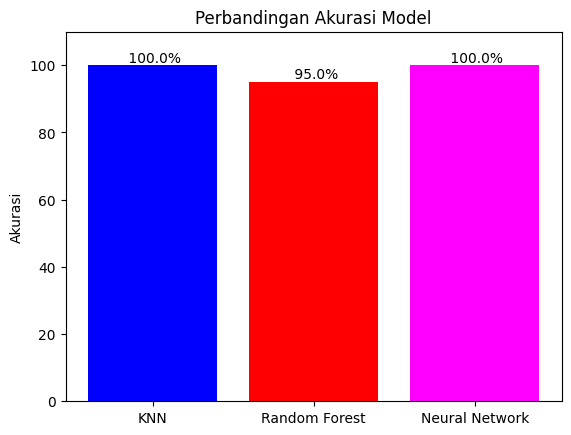

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

data = np.array ([
     [1, 2, 0], [3, 4, 2], [5, 5, 4], [2, 3, 1], [7, 5, 5],
    [0, 1, 0], [4, 4, 3], [6, 5, 4], [1, 2, 0], [8, 5, 5],
    [2, 3, 1], [5, 4, 3], [3, 3, 2], [7, 5, 5], [1, 2, 0],
    [4, 4, 2], [6, 5, 4], [0, 1, 0], [3, 3, 2], [5, 4, 3],
])
label = [
     "tidak", "ya", "ya", "tidak", "ya",
    "tidak", "ya", "ya", "tidak", "ya",
    "tidak", "ya", "tidak", "ya", "tidak",
    "ya", "ya", "tidak", "tidak", "ya"
]

scaler = MinMaxScaler()
data_normal = scaler.fit_transform(data)

models = {
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Random Forest" : RandomForestClassifier(n_estimators=100, random_state=42),
    "Neural Network" : MLPClassifier(hidden_layer_sizes=(10,5),
                                                        max_iter=1000, random_state=42),
}

print("Perbandingan model dengan cara cross validation:")
print("_" *45)

nama_model = []
rata_akurasi = []

for nama, model in models.items():
    scores = cross_val_score(model, data_normal, label, cv=5)
    print(f"{nama:15} > {scores.mean()*100:.1f}% +- {scores.std()*100:.1f}%")
    nama_model.append(nama)
    rata_akurasi.append(scores.mean() * 100)


plt.bar(nama_model, rata_akurasi, color=["blue", "red", "magenta"])
plt.title("Perbandingan Akurasi Model")
plt.ylabel("Akurasi")
plt.ylim(0,110)
for i, v in enumerate(rata_akurasi):
  plt.text(i, v+1, f" {v:.1f}%", ha="center")
plt.show()


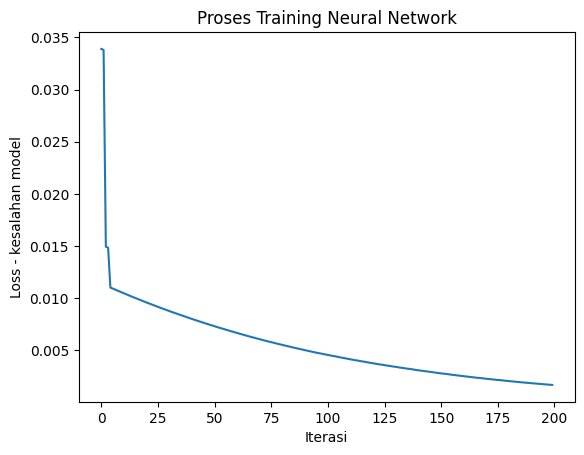


Loss awal: 0.0339
Loss akhir: 0.0017


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

data = np.array ([
    [1, 2, 0], [3, 4, 2], [5, 5, 4], [2, 3, 1], [7, 5, 5],
    [0, 1, 0], [4, 4, 3], [6, 5, 4], [1, 2, 0], [8, 5, 5],
    [2, 3, 1], [5, 4, 3], [3, 3, 2], [7, 5, 5], [1, 2, 0],
    [4, 4, 2], [6, 5, 4], [0, 1, 0], [3, 3, 2], [5, 4, 3],
])
label = [
    "tidak", "ya", "ya", "tidak", "ya",
    "tidak", "ya", "ya", "tidak", "ya",
    "tidak", "ya", "tidak", "ya", "tidak",
    "ya", "ya", "tidak", "tidak", "ya"
]

scaler = MinMaxScaler()
data_normal =scaler.fit_transform(data)

model = MLPClassifier(hidden_layer_sizes=(10,5),
                      max_iter=1000, warm_start=True, random_state=42)

losses = []
for i in range(200):
  model.fit(data_normal, label)
  losses.append(model.loss_)

plt.plot(losses)
plt.title("Proses Training Neural Network")
plt.xlabel("Iterasi")
plt.ylabel("Loss - kesalahan model")
plt.show()

print()
print("Loss awal:", round(losses[0], 4))
print("Loss akhir:", round(losses[-1], 4))